In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.datasets import cifar10
from tensorflow.keras import regularizers

###Import Data
 CIFAR10 consists of 60,000 color images (32x32 pixels, RGB) divided into 10 classes, with 6,000 images per class. The dataset is split into 50,000 training images and 10,000 test images.

In [ ]:
# Load and preprocess CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0  # Normalize pixel values

# CIFAR-10 class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

In [ ]:
# set a few hyperparameters
batch_size = 64
epochs = 2 # number of batches per epoch (50000/64) = 782

In [ ]:
x_train.shape

(50000, 32, 32, 3)

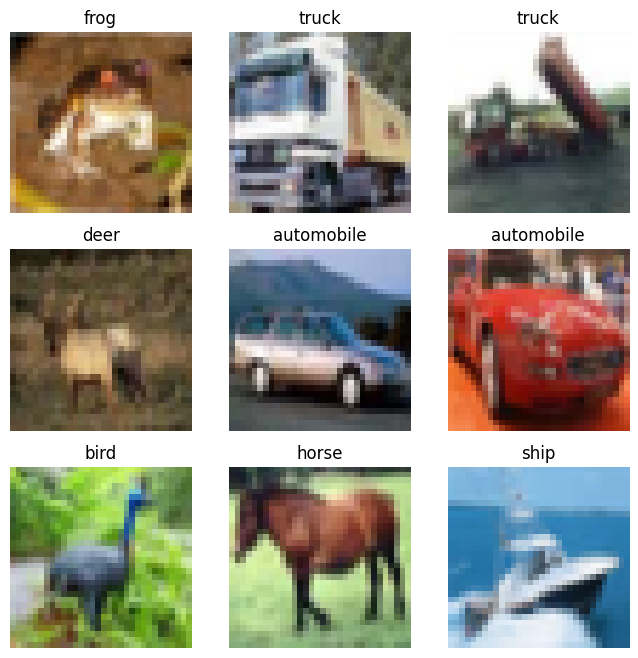

In [ ]:
# Plot first 9 images
plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])  # Extract class label
    plt.axis("off")
plt.show()

In [ ]:
# Data Augmentation

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [ ]:
# Create TensorFlow dataset with batching
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(len(x_train)).batch(batch_size)
test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(batch_size)

### Build CNN model


In [ ]:
model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compile the model


In [ ]:
model.compile(optimizer='Adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_dataset, epochs=epochs, validation_data=test_dataset)

Epoch 1/2
782/782 ━━━━━━━━━━━━━━━━━━━━ 90s 101ms/step - accuracy: 0.3288 - loss: 1.8245 - val_accuracy: 0.4335 - val_loss: 1.5105
Epoch 2/2
782/782 ━━━━━━━━━━━━━━━━━━━━ 80s 102ms/step - accuracy: 0.4334 - loss: 1.5758 - val_accuracy: 0.4540 - val_loss: 1.5412


In [ ]:
print("Final training accuracy:", history.history["accuracy"][-1])
print("Final validation accuracy:", history.history["val_accuracy"][-1])

print("Training accuracy by epoch:", history.history["accuracy"])
print("Validation accuracy by epoch:", history.history["val_accuracy"])

Final training accuracy: 0.4334399998188019
Final validation accuracy: 0.45399999618530273
Training accuracy by epoch: [0.3287999927997589, 0.4334399998188019]
Validation accuracy by epoch: [0.4334999918937683, 0.45399999618530273]


In [ ]:
model.summary()

Model: "sequential_37"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_36 (Sequential)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_81 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_75 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_82 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_76 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_83 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_77 (MaxPooling2D) │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 2, 2, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_27 (Flatten)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_81 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_54 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_82 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_55 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_83 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 504,480 (1.92 MB)

 Trainable params: 168,074 (656.54 KB)

 Non-trainable params: 256 (1.00 KB)

 Optimizer params: 336,150 (1.28 MB)

In [ ]:
def plot_predictions(images, labels, predictions, class_names, num_rows=3, num_cols=3):
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(10, 10))

    for i, ax in enumerate(axes.flat):
        index = np.random.randint(len(images))
        ax.imshow(images[index])

        predicted_label = np.argmax(predictions[index])
        true_label = int(labels[index])  # FIX: Ensure integer value

        if predicted_label >= len(class_names) or true_label >= len(class_names):
            print(f"Skipping index {index} due to out-of-bounds label.")
            continue  # Skip incorrect indices

        ax.set_title(f'Pred: {class_names[predicted_label]}\nTrue: {class_names[true_label]}',
                     color='green' if predicted_label == true_label else 'red')
        ax.axis('off')

    plt.show()


In [ ]:
# Evaluate the model
loss, accuracy = model.evaluate(test_dataset)
print(f'Test accuracy: {accuracy:.4f}')

# Make predictions
predictions = model.predict(x_test)

157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.5446 - loss: 1.3086
Test accuracy: 0.5446
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


/tmp/ipykernel_147/4097027612.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  true_label = int(labels[index])  # FIX: Ensure integer value


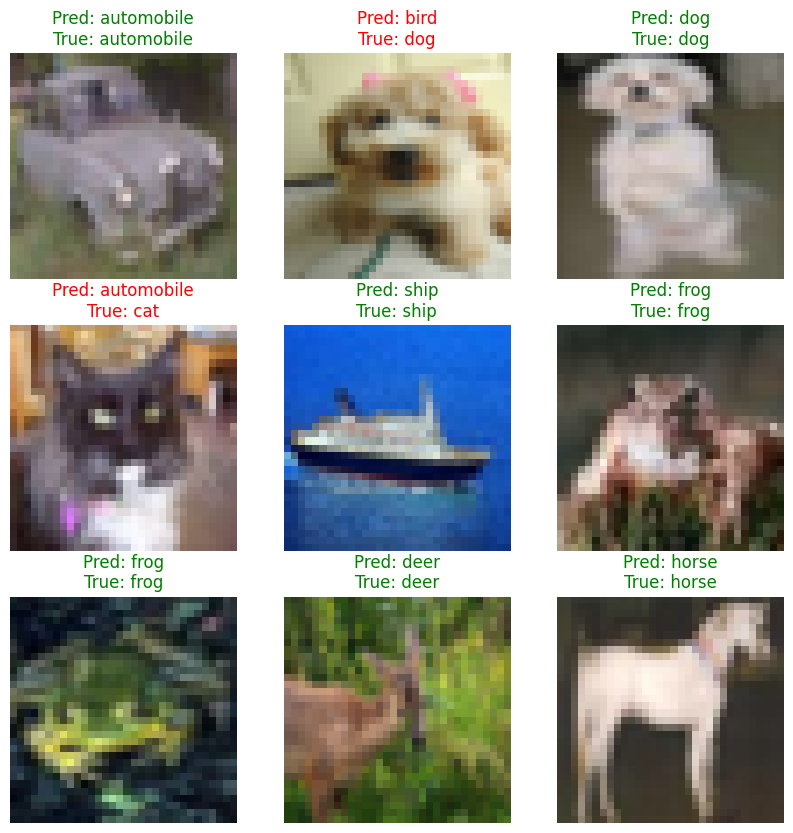

In [ ]:
# Plot sample predictions
plot_predictions(x_test, y_test, predictions, class_names)

In [ ]:
print("Final training accuracy:", history.history["accuracy"][-1])
print("Final validation accuracy:", history.history["val_accuracy"][-1])

Final training accuracy: 0.5647199749946594
Final validation accuracy: 0.5446000099182129


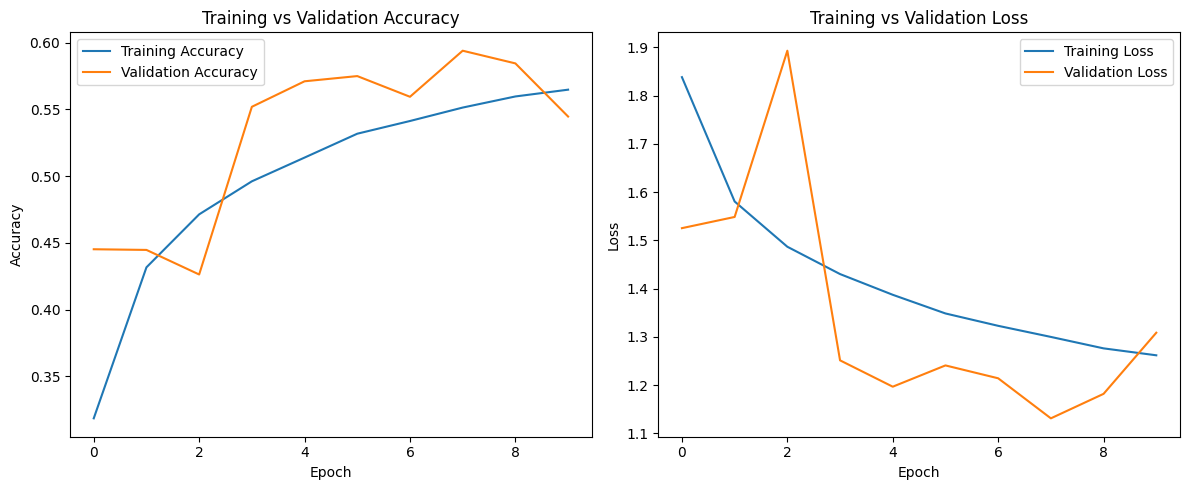

In [ ]:
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score

# Get model predictions
predictions = model.predict(x_test)
y_pred = np.argmax(predictions, axis=1)
y_true = y_test.flatten()

# Select class: cat
cat_class = 3  # 'cat'

# Convert to one-vs-rest binary labels
y_true_cat = (y_true == cat_class).astype(int)
y_pred_cat = (y_pred == cat_class).astype(int)

precision_cat = precision_score(y_true_cat, y_pred_cat)
recall_cat = recall_score(y_true_cat, y_pred_cat)

print("Precision for cat:", precision_cat)
print("Recall for cat:", recall_cat)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
Precision for cat: 0.47506561679790027
Recall for cat: 0.181


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


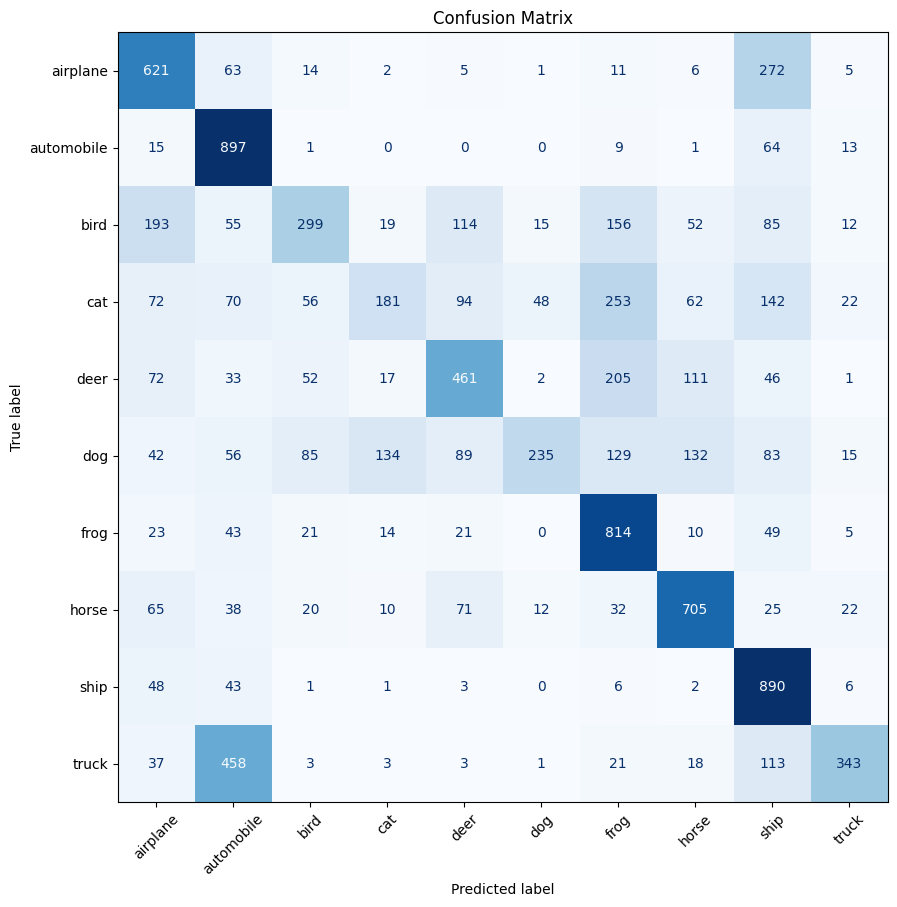

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions
predictions = model.predict(x_test)
y_pred = np.argmax(predictions, axis=1)
y_true = y_test.flatten()

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45, ax=ax, colorbar=False)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

top_pairs = []
for _ in range(5):
    idx = np.unravel_index(np.argmax(cm_no_diag), cm_no_diag.shape)
    top_pairs.append((class_names[idx[0]], class_names[idx[1]], cm_no_diag[idx]))
    cm_no_diag[idx] = 0

print("Top confused class pairs:")
for true_class, pred_class, count in top_pairs:
    print(f"True: {true_class}, Predicted: {pred_class}, Count: {count}")

Top confused class pairs:
True: truck, Predicted: automobile, Count: 458
True: airplane, Predicted: ship, Count: 272
True: cat, Predicted: frog, Count: 253
True: deer, Predicted: frog, Count: 205
True: bird, Predicted: airplane, Count: 193
